# Study extracted traces

Jupyter notebook that studies the background noise, SNR signal and PSD of the extracted traces.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
from glob import glob 
from scipy.signal import periodogram

from SPETCES.imported_fcts import master_path, PSD_dataset, measure_SNR, measure_sigma, plot_loghist

# Opening gathered noise/sims

In [34]:
# library_path = f'{master_path}/gathered_traces/sims_NJ'
library_path = '/sps/grand/jlavoisier/output/ML_cuts/datasets/dataset_verif/marion_202512_sure'

data_type = library_path.split('/')[-1]  # 'sims_AN' or 'noise'

repert_traces = sorted(glob(library_path + '/*traces.npy'))
repert_info = sorted(glob(library_path + '/*info.npy'))

info_batch = np.empty((0,11))
for i in range(len(repert_info)) :
    info_i = np.load(repert_info[i])
    info_adapted = info_i.copy()
    info_adapted[:,0] += info_batch.shape[0]  # Adjust trace index
    if i>0:
        info_adapted[:,1] += info_batch[-1,1]  # Adjust event index
    info_batch = np.append(info_batch, info_adapted, axis=0)

print(f'Number of traces gathered: {info_batch.shape}')
print(info_batch)

Number of traces gathered: (615, 11)
[[0.00000000e+00 2.02507071e+13 4.79000000e+02 ... 1.54492339e+01
  1.34218243e+00 4.95205750e+00]
 [1.00000000e+00 2.02507071e+13 4.79000000e+02 ... 1.59042026e+01
  1.34218243e+00 4.95205750e+00]
 [2.00000000e+00 2.02507071e+13 4.79000000e+02 ... 1.50828097e+01
  1.34218243e+00 4.95205750e+00]
 ...
 [6.12000000e+02 1.47831331e+15 1.18900000e+03 ... 1.29342960e+01
  1.22255227e+00 1.03696785e+00]
 [6.13000000e+02 1.47831331e+15 1.18900000e+03 ... 1.26803367e+01
  1.22255227e+00 1.03696785e+00]
 [6.14000000e+02 1.47831331e+15 1.18900000e+03 ... 1.26454962e+01
  1.22255227e+00 1.03696785e+00]]


## PSD

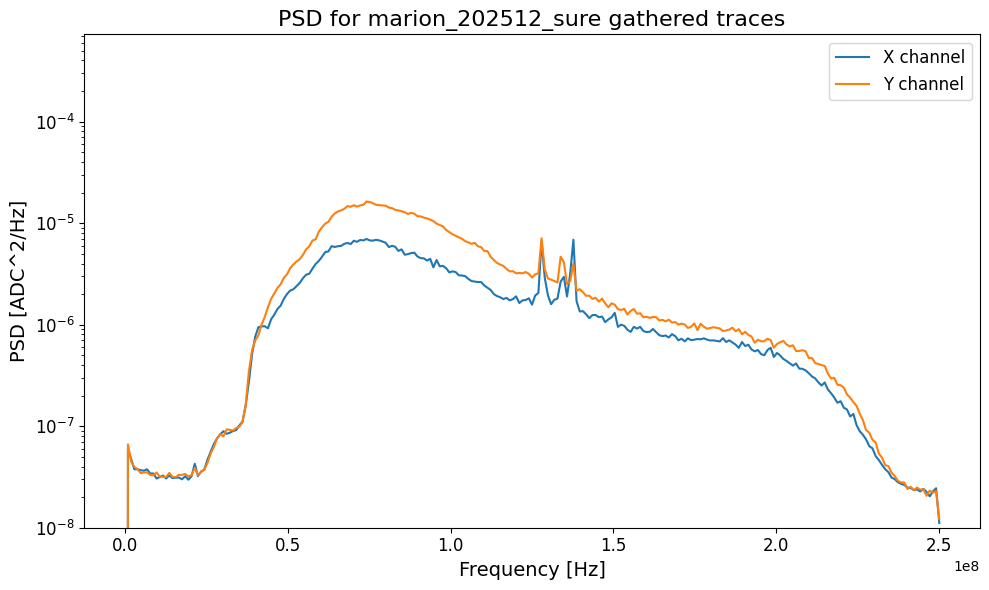

In [35]:
# PSD_dataset(repert_traces, 
#             f"{master_path}/plots/gathered_traces_study_plots/{data_type}/PSD",
#             title=None
#             )
save_path_PSD = f"{master_path}/plots/gathered_traces_study_plots/{data_type}/PSD"

fs = 5e8 # in Hz, sampling frequency for the traces

data = np.load(repert_traces[0])
plt.figure(figsize=(10,6))
# fx, Pxx = periodogram(data[0,0,:], fs=fs)
# fy, Pxy = periodogram(data[0,1,:], fs=fs)
fx, Pxx = periodogram(data[0,:,0], fs=fs)
fy, Pxy = periodogram(data[0,:,1], fs=fs)

div = 0

for i in range(len(repert_traces)) :
    data = np.load(repert_traces[i])
    for j in range(data.shape[0]):
        if i==0 and j==0 :
            continue
        # _, Pxx1 = periodogram(data[j,0,:], fs=fs)
        # _, Pxy1 = periodogram(data[j,1,:], fs=fs)

        _, Pxx1 = periodogram(data[j,:,0], fs=fs)
        _, Pxy1 = periodogram(data[j,:,1], fs=fs)

        Pxx += Pxx1
        Pxy += Pxy1
        div += 1

plt.semilogy(fx, Pxx/div,
                label='X channel')
plt.semilogy(fy, Pxy/div,
                label='Y channel')
plt.xlabel('Frequency [Hz]',
            fontsize=14)
plt.ylabel('PSD [ADC^2/Hz]',
            fontsize=14)
plt.ylim(ymin=1e-8)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.title(f'PSD for {data_type} gathered traces',
            wrap=True,
            fontsize=16)
plt.legend(fontsize=12)
plt.tight_layout()
os.makedirs(os.path.dirname(save_path_PSD), exist_ok=True)
plt.savefig(save_path_PSD)
plt.show()
plt.close()

In [4]:
# Now plot the PSD histograms as function of SNR (2 curves per SNR bracket, one continuous, one hatched)

## Signal-over-Noise Ratio

[ 8.35408762  6.88317373  5.06904957  6.16629196  6.42595266  7.88918706
  5.05973497  6.12231987  6.35819257  5.75512831  3.983178    3.39872943
  3.44511254  3.24063012  3.45387584  3.43169604  3.43693512  5.60585718
  3.90678151  3.38524703  4.04656136  4.49253936  3.6445408   4.50316947
 15.3227591  15.05716218 10.2762523   4.78392406  3.4691991   3.72401127
  3.24104259  6.44202347  4.6598616   8.9987034  11.82944939  3.07052676
  7.6233166   3.81629531  4.44548313  3.42950729  3.6184336   4.04653478
  4.12575042  3.4888577   3.56630168  3.14622796  3.84082672  3.99546758
  3.12466495  3.22128021  3.21459089  3.22957219  6.05233791  5.6407156
  3.58658344  4.6299098   7.05411709  9.73701097  5.34525633  6.94800887
 32.46080892 40.38083943 33.02344948 45.8396218  18.84889319 21.38331596
  3.82709464  3.71771558  3.65387742  3.67698046  3.7564136   7.04669013
  3.00778366 12.78805983  8.58615732 12.44465643  9.85228817 11.97927817
  7.26311873  7.45181706  5.39082093  8.53284269 10.

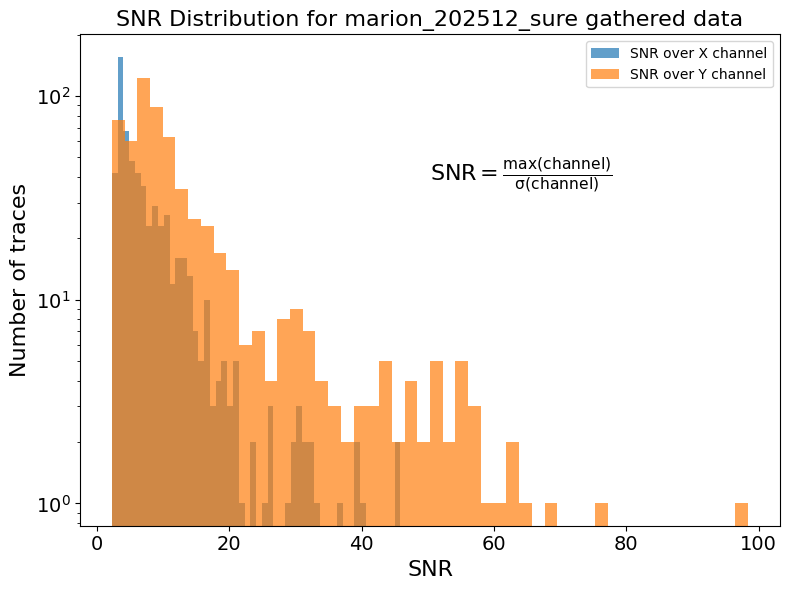

In [36]:
SNR_X_gathered = info_batch[:,5]
SNR_Y_gathered = info_batch[:,6]

plt.figure(figsize=(8,6))

plt.hist(SNR_X_gathered, 
         bins=50, 
        #  color='blue', 
         alpha=0.7,
         label='SNR over X channel'
         )

plt.hist(SNR_Y_gathered, 
         bins=50, 
        #  color='red', 
         alpha=0.7,
         label='SNR over Y channel')
print(SNR_X_gathered)

plt.annotate(r"$\rm SNR = \frac{\max(\rm channel)}{\sigma (\rm channel)}$",
             xy=(.5, .7),
             xycoords='axes fraction',
             fontsize=16
             )

plt.xlabel('SNR', fontsize=16)
plt.ylabel('Number of traces', fontsize=16)
plt.yscale('log')
plt.title(f'SNR Distribution for {data_type} gathered data', fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.legend(loc='upper right')
plt.tight_layout()
plt.savefig(f"{master_path}/plots/gathered_traces_study_plots/{data_type}/SNR_distribution.png")
plt.show()
plt.close()

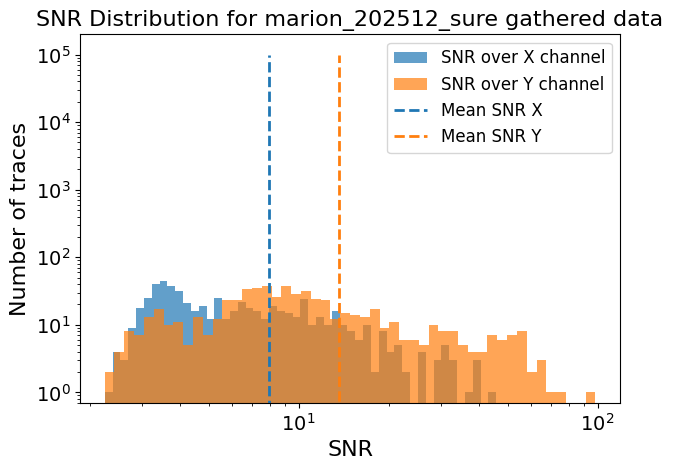

Mean SNR over X channel: 7.926593595771532
Mean SNR over Y channel: 13.605734326690873
Proportion over 4 SNR in X channel: 0.6764227642276422
Proportion over 4 SNR in Y channel: 0.8878048780487805


In [37]:
# plt.figure(figsize=(8,6))

plot_loghist(SNR_X_gathered, 
            bins=50, 
            label='SNR over X channel', 
            alpha=0.7)

plot_loghist(SNR_Y_gathered, 
            bins=50, 
            label='SNR over Y channel', 
            alpha=0.7)

# plt.annotate(r"$\rm SNR = \frac{\max(\rm channel)}{\sigma (\rm channel)}$",
#              xy=(.5, .7),
#              xycoords='axes fraction',
#              fontsize=16
#              )

plt.plot(np.zeros(10) + np.mean(SNR_X_gathered), 
         np.linspace(2e-1,1e5, 10), 
         color='tab:blue',
         linewidth=2,
         linestyle='--',
         label='Mean SNR X'
         )

plt.plot(np.zeros(10) + np.mean(SNR_Y_gathered), 
         np.linspace(1e-1,1e5, 10), 
         color='tab:orange',
         linewidth=2,
         linestyle='--',
         label='Mean SNR Y'
         ) # to display the means of the histograms

plt.xlabel('SNR', fontsize=16)
plt.ylabel('Number of traces', fontsize=16)

plt.yscale('log')

plt.title(f'SNR Distribution for {data_type} gathered data', fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.ylim(ymin=7e-1)
plt.legend(loc='upper right',
           fontsize=12)
plt.tight_layout()
plt.savefig(f"{master_path}/plots/gathered_traces_study_plots/{data_type}/SNR_distribution_log.png")
plt.show()
plt.close()

print("Mean SNR over X channel:", np.mean(SNR_X_gathered))
print("Mean SNR over Y channel:", np.mean(SNR_Y_gathered))
print("Proportion over 4 SNR in X channel:", np.sum(SNR_X_gathered > 4)/len(SNR_X_gathered))
print("Proportion over 4 SNR in Y channel:", np.sum(SNR_Y_gathered > 4)/len(SNR_Y_gathered))

[1014. 1020. 1019. 1012. 1011.]
File /sps/grand/jlavoisier/output/ML_cuts/datasets/dataset_verif/marion_202512_sure/20250707_065719_479_info.npy contains traces with SNR > 5
[1014. 1020. 1019. 1012. 1011.]


ValueError: x and y must have same first dimension, but have shapes (512,) and (2,)

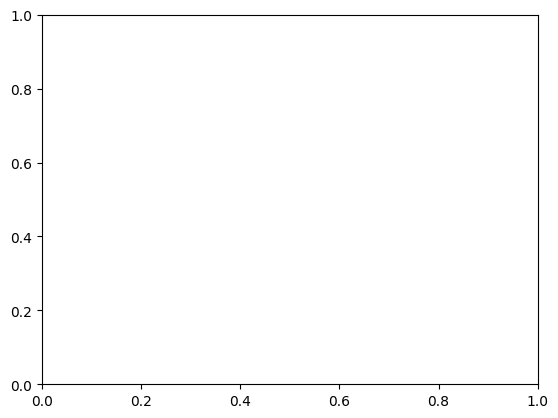

In [7]:
for i in range(len(repert_info)) :
    info_search = np.load(repert_info[i])
    SNR_X_search = info_search[:,4]
    SNR_Y_search = info_search[:,5]
    print(SNR_X_search)
    if np.sum(SNR_X_search > 350) > 0 or np.sum(SNR_Y_search > 350) > 0 :
        print(f"File {repert_info[i]} contains traces with SNR > 5")
        print(SNR_X_search)
        trace_found = np.load(repert_traces[i])
        trace_SNR_anormal = trace_found[(SNR_X_search > 350)]
        break

plt.plot(np.linspace(0,1024,512),
         trace_SNR_anormal[0,0,:],
         label='X channel'
         )
plt.plot(np.linspace(0,1024,512),
         trace_SNR_anormal[0,1,:],
         label='Y channel'
         )
plt.xlabel('Time [ns]', fontsize=16)
plt.ylabel('ADC counts', fontsize=16)
plt.title('Trace with abnormally high SNR', fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.legend()
plt.tight_layout()
plt.show()

## Background noise

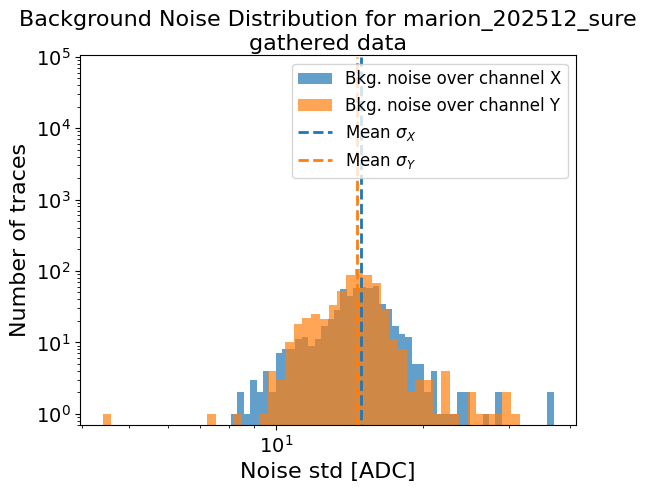

In [38]:
sigma_X_gathered = info_batch[:,7]
sigma_Y_gathered = info_batch[:,8]

# plt.figure(figsize=(8,6))
plot_loghist(sigma_X_gathered, bins=50, label='Bkg. noise over channel X', alpha=0.7)
plot_loghist(sigma_Y_gathered, bins=50, label='Bkg. noise over channel Y', alpha=0.7)


# plt.annotate(r"${\sigma (\rm channel)} = \sqrt{\mathbb{V}(\rm channel w/o(pulse))}$",
#              xy=(.3, .65),
#              xycoords='axes fraction',
#              fontsize=16
#              )

plt.plot(np.zeros(10) + np.mean(sigma_X_gathered), 
         np.linspace(2e-1,1e5, 10), 
         color='tab:blue',
         linewidth=2,
         linestyle='--',
         label=r'Mean $\sigma_X$'
         ) # to display the means of the histograms

plt.plot(np.zeros(10) + np.mean(sigma_Y_gathered), 
         np.linspace(1e-1,1e5, 10), 
         color='tab:orange',
         linewidth=2,
         linestyle='--',
         label=r'Mean $\sigma_Y$'
         ) # to display the means of the histograms

plt.xlabel('Noise std [ADC]', fontsize=16)
plt.ylabel('Number of traces', fontsize=16)
plt.ylim(ymin=7e-1)
plt.title(f'Background Noise Distribution for {data_type} gathered data', 
          wrap=True,
          fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.yscale('log')
plt.legend(loc='upper right',
           fontsize=12)
plt.savefig(f"{master_path}/plots/gathered_traces_study_plots/{data_type}/Background_noise_log.png")
plt.show()
plt.close()

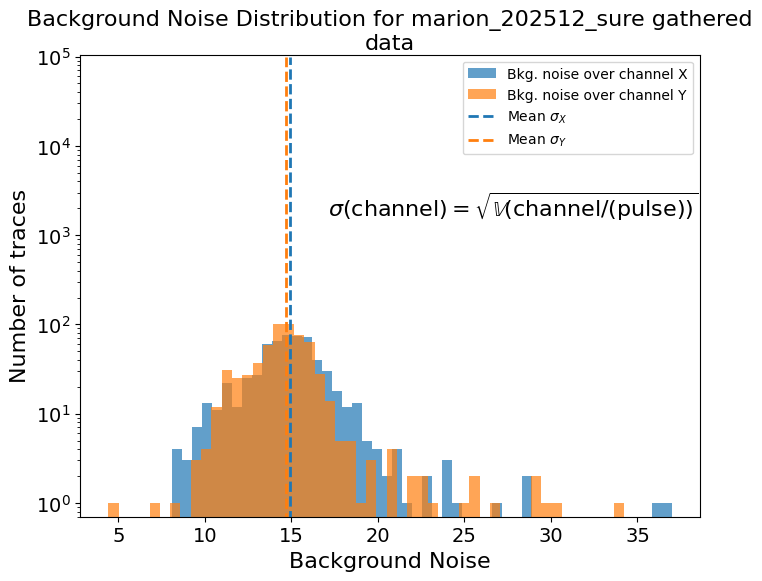

Mean background noise over X channel: 14.931230192232494
Standard deviation of background noise over X channel: 2.8269687704783832
Mean background noise over Y channel: 14.662212613288604
Standard deviation of background noise over Y channel: 2.6140119467965603
number of traces with background noise X between 10 and 20:  582
number of traces with background noise Y between 10 and 20:  589
Both:  567


In [39]:
plt.figure(figsize=(8,6))
plt.hist(sigma_X_gathered, 
         bins=50, 
         label='Bkg. noise over channel X',
        #  color='blue', 
         alpha=0.7
         )
plt.hist(sigma_Y_gathered, 
         bins=50, 
         label='Bkg. noise over channel Y',
        #  color='blue', 
         alpha=0.7
         )

plt.annotate(r"${\sigma (\rm channel)} = \sqrt{\mathbb{V}(\rm channel/(pulse))}$",
             xy=(.4, .65),
             xycoords='axes fraction',
             fontsize=16
             )

plt.plot(np.zeros(10) + np.mean(sigma_X_gathered), 
         np.linspace(2e-1,1e5, 10), 
         color='tab:blue',
         linewidth=2,
         linestyle='--',
         label=r'Mean $\sigma_X$'
         ) # to display the means of the histograms

plt.plot(np.zeros(10) + np.mean(sigma_Y_gathered), 
         np.linspace(1e-1,1e5, 10), 
         color='tab:orange',
         linewidth=2,
         linestyle='--',
         label=r'Mean $\sigma_Y$'
         ) # to display the means of the histograms

plt.xlabel('Background Noise', fontsize=16)
plt.ylabel('Number of traces', fontsize=16)
plt.title(f'Background Noise Distribution for {data_type} gathered data', 
          wrap=True,
          fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.ylim(ymin=7e-1)
plt.yscale('log')
plt.legend(loc='upper right')
plt.savefig(f"{master_path}/plots/gathered_traces_study_plots/{data_type}/Background_noise.png")
plt.show()
plt.close()

print("Mean background noise over X channel:", np.mean(sigma_X_gathered))
print("Standard deviation of background noise over X channel:", np.std(sigma_X_gathered))
print("Mean background noise over Y channel:", np.mean(sigma_Y_gathered))
print("Standard deviation of background noise over Y channel:", np.std(sigma_Y_gathered))

print("number of traces with background noise X between 10 and 20: ", np.sum((sigma_X_gathered > 10) & (sigma_X_gathered < 20)))
print("number of traces with background noise Y between 10 and 20: ", np.sum((sigma_Y_gathered > 10) & (sigma_Y_gathered < 20)))
print("Both: ", np.sum((sigma_X_gathered > 10) & (sigma_X_gathered < 20) & (sigma_Y_gathered > 10) & (sigma_Y_gathered < 20)))

[0. 0. 0. ... 0. 0. 0.]
File /sps/grand/jlavoisier/output/ML_cuts/gathered_traces/sims_NJ/adc_10506-9258_L1_0000.root/info.npy contains traces with bckg > 2000
[0. 0. 0. ... 0. 0. 0.]



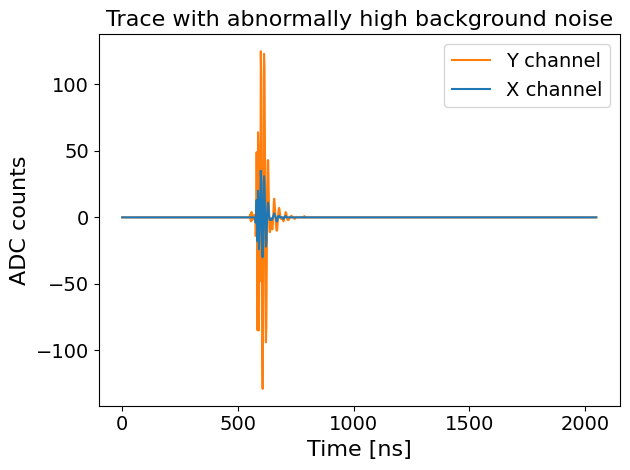

In [51]:
for i in range(len(repert_info)) :
    info_search = np.load(repert_info[i])
    sigma_X_search = info_search[:,7]
    sigma_Y_search = info_search[:,8]
    print(sigma_X_search)
    if np.sum(sigma_X_search < 20) > 0 or np.sum(sigma_Y_search < 20) > 0 :
        print(f"File {repert_info[i]} contains traces with bckg > 2000")
        print(sigma_X_search)
        trace_found = np.load(repert_traces[i])
        trace_sigma_anormal = trace_found[(sigma_Y_search < 20)]
        print()
        break

# plt.figure(figsize=(12,6))
plt.plot(np.linspace(0,2048,1024),
         trace_sigma_anormal[0,1,:],
         label='Y channel',
         color='tab:orange'
         )
plt.plot(np.linspace(0,2048,1024),
         trace_sigma_anormal[0,0,:],
         label='X channel',
         color='tab:blue'
         )


plt.xlabel('Time [ns]', fontsize=16)
plt.ylabel('ADC counts', fontsize=16)
plt.title('Trace with abnormally high background noise', fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.legend(fontsize=14)
plt.tight_layout()
plt.show()

## Arrival direction

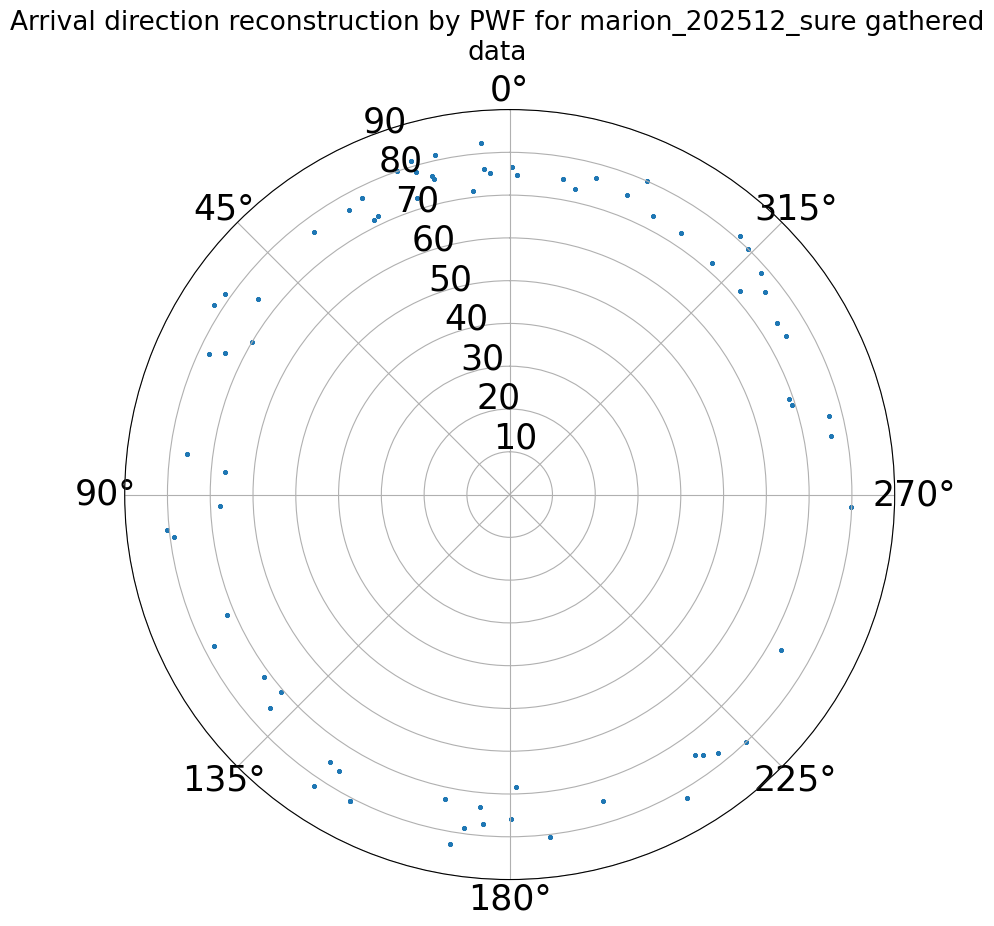

In [40]:
_, index_theta = np.unique(info_batch[:,9], return_index=True)
_, index_phi = np.unique(info_batch[:,10], return_index=True)

theta_unique = info_batch[:,9][index_theta]
phi_unique = info_batch[:,10][index_phi]

theta = info_batch[:,9]
phi = info_batch[:,10]

# --- Arrival direction study ---
fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(projection='polar')

# fig.suptitle(f"Arrival direction reconstruction by PWF on {day_analysis}/{month}",
#              fontsize=19,
#              wrap=True
#              )
fig.suptitle(f"Arrival direction reconstruction by PWF for {data_type} gathered data",
             fontsize=19,
             wrap=True
             )


ax.scatter(phi, 
            theta*180/np.pi,
            alpha=1, 
            s=5
            )


ax.tick_params(axis='both', 
                  labelsize=25)

ax.set_theta_zero_location("N")
ax.set_ylim(0,90)
# print(colors_day)
plt.show()

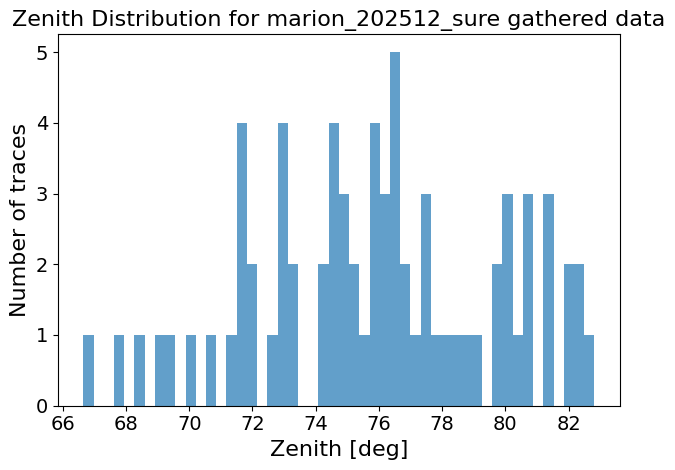

In [41]:
plt.hist(theta_unique*180/np.pi,
         bins=50,
         alpha=0.7
         )
plt.xlabel('Zenith [deg]', fontsize=16)
plt.ylabel('Number of traces', fontsize=16)
plt.title(f'Zenith Distribution for {data_type} gathered data', fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tight_layout()
plt.show()

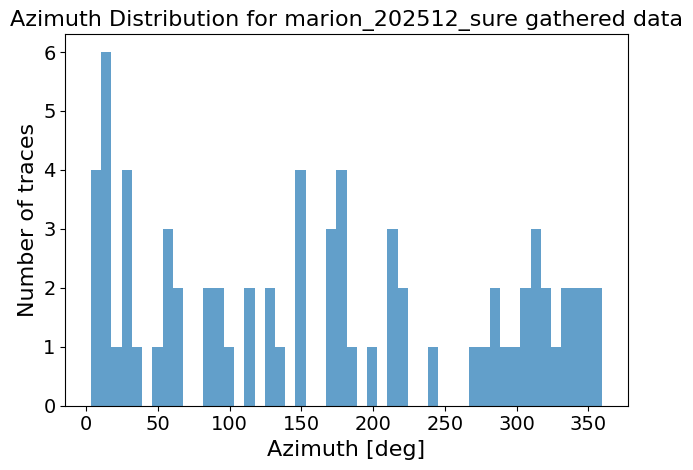

In [42]:
plt.hist(phi_unique*180/np.pi,
         bins=50,
         alpha=0.7
         )
plt.xlabel('Azimuth [deg]', fontsize=16)
plt.ylabel('Number of traces', fontsize=16)
plt.title(f'Azimuth Distribution for {data_type} gathered data', fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tight_layout()
plt.show()

## Number of antennas per event

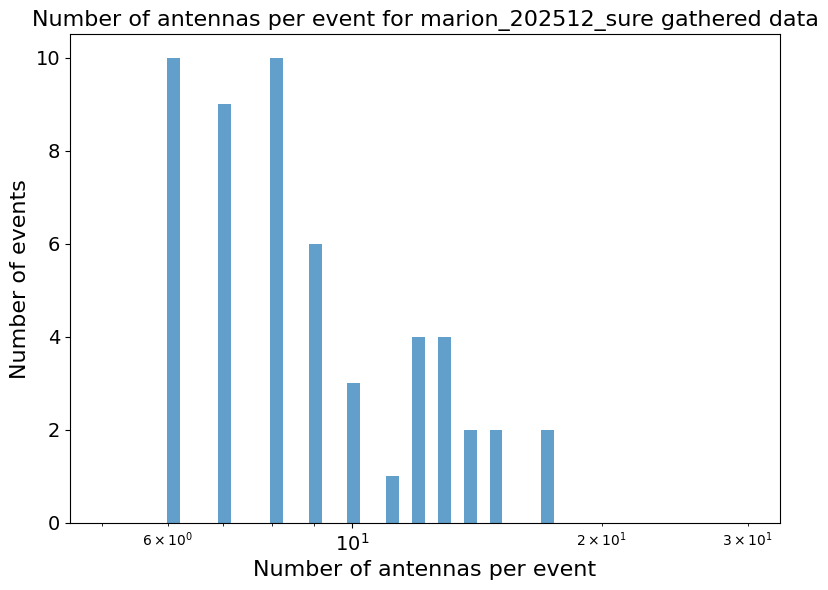

In [43]:
nb_antennas_per_event = np.unique(info_batch[:,1], return_counts=True)[1]

plt.figure(figsize=(8,6))
plot_loghist(nb_antennas_per_event, 
            bins=50, 
            label='Number of antennas per event', 
            alpha=0.7)
plt.xlabel('Number of antennas per event', fontsize=16)
plt.ylabel('Number of events', fontsize=16)
plt.title(f'Number of antennas per event for {data_type} gathered data', fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tight_layout()
plt.savefig(f"{master_path}/plots/gathered_traces_study_plots/{data_type}/nb_antennas_per_event.png")
plt.show()
plt.close()

In [52]:
library_path = '/sps/grand/jlavoisier/output/ML_cuts/datasets/dataset_verif/marion_202512_sure'

data_type = library_path.split('/')[-1]  # 'sims_AN' or 'noise'

repert_traces = sorted(glob(library_path + '/*traces.npy'))
repert_info = sorted(glob(library_path + '/*info.npy'))

trace_batch = np.empty((0,512, 2))
for i in range(len(repert_traces)) :
    traces_i =  np.load(repert_traces[i])
    trace_batch = np.append(trace_batch, traces_i, axis=0)

info_batch = np.empty((0,11))
for i in range(len(repert_info)) :
    info_i = np.load(repert_info[i])
    info_adapted = info_i.copy()
    info_adapted[:,0] += info_batch.shape[0]  # Adjust trace index
    if i>0:
        info_adapted[:,1] += info_batch[-1,1]  # Adjust event index
    info_batch = np.append(info_batch, info_adapted, axis=0)

print(f'Number of traces gathered: {info_batch.shape}, {trace_batch.shape[0] == info_batch.shape[0]}')
# print(info_batch[:,0])

indexes_save = np.int32(info_batch[(info_batch[:,7] > 10) & (info_batch[:,7] < 20) & (info_batch[:,8] > 10) & (info_batch[:,8] < 20) & (np.array([info_batch[:,5] >=4, info_batch[:,6] >=4]).any(axis=0))][:,0])
print(indexes_save.shape)

traces_to_save = trace_batch[indexes_save]
info_batch_to_save = info_batch[indexes_save]
for i in range(len(indexes_save)) :
    info_batch_to_save[i,0] = i  # re-indexing the traces

np.save(f'/sps/grand/jlavoisier/output/ML_cuts/datasets/dataset_real_CR2/raw_dataset/marion_202512_sure_{indexes_save.shape[0]}_traces.npy', traces_to_save)
np.save(f'/sps/grand/jlavoisier/output/ML_cuts/datasets/dataset_real_CR2/raw_dataset/marion_202512_sure_{indexes_save.shape[0]}_info.npy', info_batch_to_save)

Number of traces gathered: (615, 11), True
(567,)


In [ ]:

valid_traces = np.empty((0,512,2))
valid_info = np.empty((0,11))

for repert in repertories:
    # Load the traces and info files
    traces = np.load(f'{repert}/traces.npy')
    info = np.load(f'{repert}/info.npy')

    # Look into the info if the background noise is in the good interval
    mask_bkg = ((info[:,7] >= 10) & (info[:,7] <= 20) & (info[:,8] >= 10) & (info[:,8] <= 20) & (np.array([info[:,5] >=4, info[:,6] >=4]).any(axis=0)))
    if np.any(mask_bkg):
        info_to_add = info[mask_bkg]
        traces_to_add = traces[mask_bkg.astype(bool)]

        valid_info = np.append(valid_info, info_to_add, axis=0)
        valid_traces = np.append(valid_traces, traces_to_add, axis=0)

# Opening a dataset

Open the right dataset

In [53]:
dataset_path_traces = f"{master_path}/datasets/dataset_real_CR2/raw_dataset/marion_202512_sure_567_traces.npy"
dataset_path_info = f"{master_path}/datasets/dataset_real_CR2/raw_dataset/marion_202512_sure_567_info.npy"
dataset_info = np.load(dataset_path_info)
data = np.load(dataset_path_traces)

dir_for_traces = 'marion_202512_sure'

dataset_type = dataset_path_traces.split("/")[-2]
name_output_dir = dataset_path_traces.split("/")[-1].replace("_traces.npy", "_study")
os.makedirs(f"{master_path}/plots/{dataset_type}/{name_output_dir}", exist_ok=True)

## Example of traces

In [54]:
i = 0

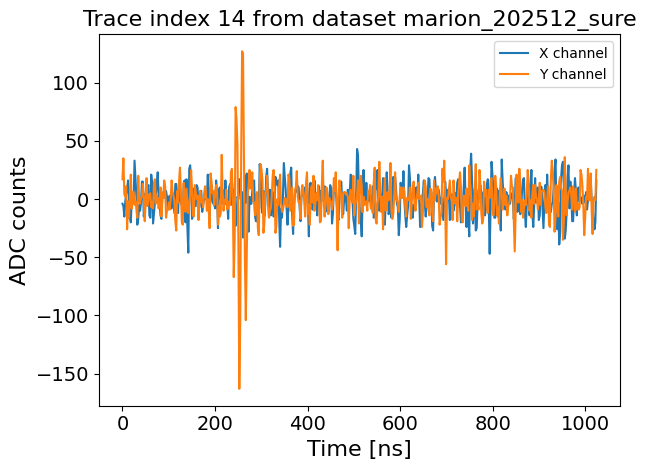

In [69]:

plt.plot(np.linspace(0,1024,512),
         data[i,:,0],
         label='X channel'
)
plt.plot(np.linspace(0,1024,512),
         data[i,:,1],
         label='Y channel'
)
plt.xlabel('Time [ns]', fontsize=16)
plt.ylabel('ADC counts', fontsize=16)
plt.title(f'Trace index {i} from dataset {dir_for_traces}', fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.legend()
plt.tight_layout()
plt.show()

i+=1

## PSD

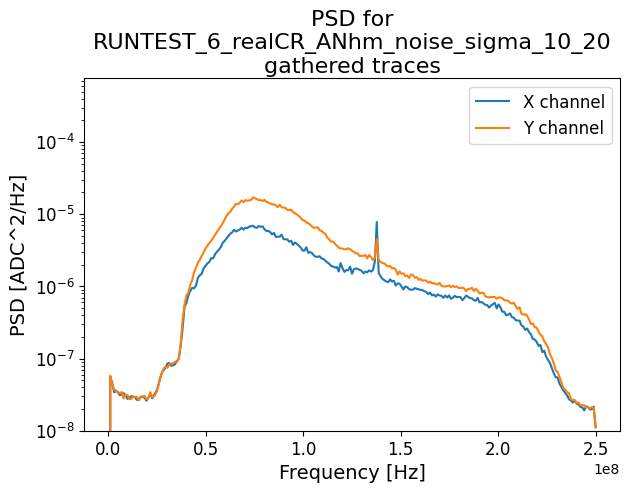

In [ ]:
save_path_PSD = f"{master_path}/plots/{dataset_type}/{name_output_dir}/PSD"

os.makedirs(f"{master_path}/plots/{dataset_type}/trace/{dir_for_traces}", exist_ok=True)

fs = 5e8 # in Hz, sampling frequency for the traces

plt.figure(figsize=(10,6))
fx, Pxx = periodogram(data[0,:,0], fs=fs)
fy, Pxy = periodogram(data[0,:,1], fs=fs)

for j in range(500) :
    plt.plot(np.linspace(0,1024, 512), 
                data[j,:,0],
                label='X channel',
                color='tab:blue'
            )
    plt.plot(np.linspace(0,1024, 512), data[j,:,1],
            label='Y channel',
            color='tab:orange'
            )
    plt.title(f'Example trace from {dataset_type}')
    plt.xlabel('Time [ns]', fontsize=16)
    plt.ylabel('ADC counts', fontsize=16)
    plt.legend(fontsize=14)
    plt.savefig(f'{master_path}/plots/{dataset_type}/trace/{dir_for_traces}/example_{dir_for_traces}_trace_RUNTEST_6_{j}_filtered.png')
    plt.close()

div = 0

for j in range(1, data.shape[0]):
    _, Pxx1 = periodogram(data[j,:,0], fs=fs)
    Pxx += Pxx1
    _, Pxy1 = periodogram(data[j,:,1], fs=fs)
    Pxy += Pxy1
    div += 1

plt.semilogy(fx, Pxx/div,
                label='X channel')
plt.semilogy(fy, Pxy/div,
                label='Y channel')
plt.xlabel('Frequency [Hz]',
            fontsize=14)
plt.ylabel('PSD [ADC^2/Hz]',
            fontsize=14)
plt.ylim(ymin=1e-8)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.title(f'PSD for {dataset_type} gathered traces',
            wrap=True,
            fontsize=16)
plt.legend(fontsize=12)
plt.tight_layout()
os.makedirs(os.path.dirname(save_path_PSD), exist_ok=True)
plt.savefig(save_path_PSD)
plt.show()
plt.close()

## Signal-over-Noise Ratio

Plots and saves the distribution for SNR of traces.

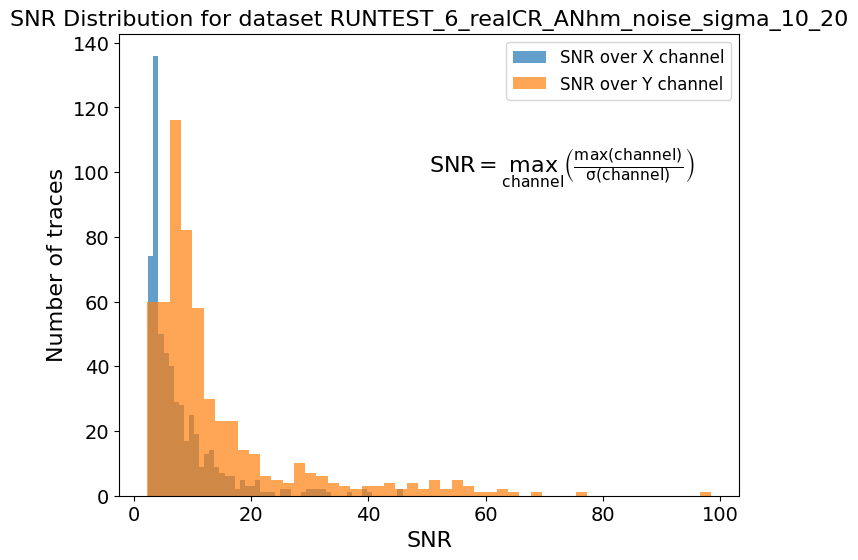

In [18]:
SNR_X = dataset_info[:,5]
SNR_Y = dataset_info[:,6]

plt.figure(figsize=(8,6))
plt.hist(SNR_X, 
         bins=50, 
        #  color='blue', 
         label='SNR over X channel',
         alpha=0.7
         )
plt.hist(SNR_Y, 

         bins=50, 
        #  color='red', 
         label='SNR over Y channel',
         alpha=0.7
         )
plt.annotate(r"$\rm SNR = \max_{\rm channel} \left(\frac{\max(\rm channel)}{\sigma (\rm channel)}\right)$",
             xy=(.5, .7),
             xycoords='axes fraction',
             fontsize=16
             )

plt.xlabel('SNR', fontsize=16)
plt.ylabel('Number of traces', fontsize=16)
plt.title(f'SNR Distribution for dataset {dataset_type}', fontsize=16)
plt.legend(loc='upper right',
           fontsize=12)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.savefig(f"{master_path}/plots/{dataset_type}/{name_output_dir}/SNR_distribution.png")
plt.show()
plt.close()

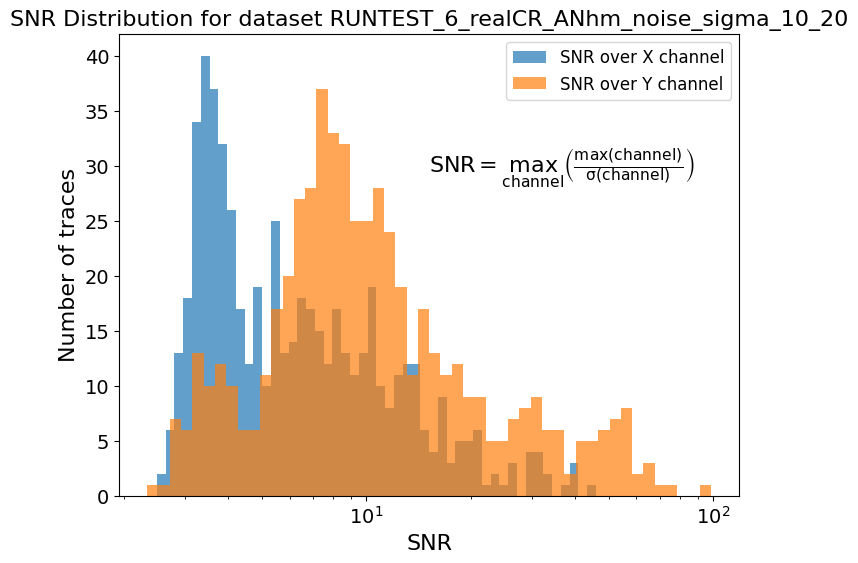

In [19]:
SNR_X = dataset_info[:,5]
SNR_Y = dataset_info[:,6]

plt.figure(figsize=(8,6))

plot_loghist(SNR_X, 
            bins=50, 
            label='SNR over X channel', 
            alpha=0.7)
plot_loghist(SNR_Y, 
            bins=50, 
            label='SNR over Y channel', 
            alpha=0.7)
plt.annotate(r"$\rm SNR = \max_{\rm channel} \left(\frac{\max(\rm channel)}{\sigma (\rm channel)}\right)$",
             xy=(.5, .7),
             xycoords='axes fraction',
             fontsize=16
             )

plt.xlabel('SNR', fontsize=16)
plt.ylabel('Number of traces', fontsize=16)
plt.title(f'SNR Distribution for dataset {dataset_type}', fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.legend(loc='upper right',
           fontsize=12)
plt.savefig(f"{master_path}/plots/{dataset_type}/{name_output_dir}/SNR_distribution_log.png")
plt.show()
plt.close()

## Background noise

Plots and saves the distribution for background noise of traces.

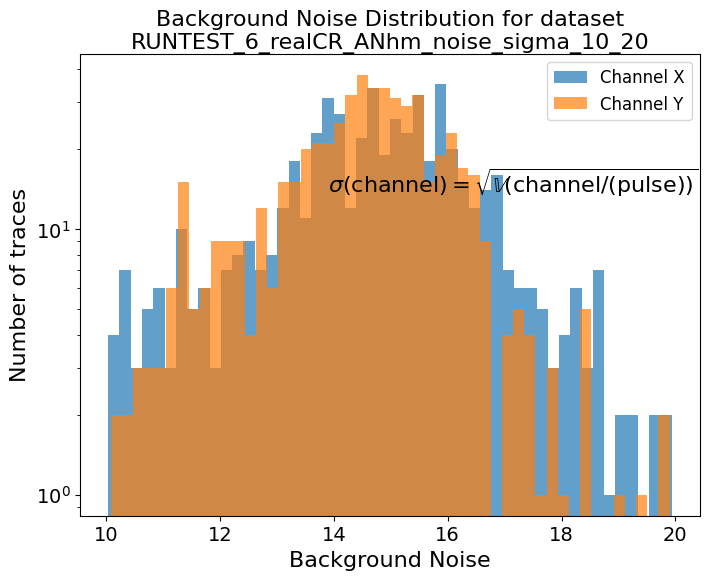

In [20]:
sigma_X = dataset_info[:,7]
sigma_Y = dataset_info[:,8]

plt.figure(figsize=(8,6))
plt.hist(sigma_X, 
         bins=50, 
         label='Channel X',
        #  color='blue', 
         alpha=0.7
         )
plt.hist(sigma_Y, 
         bins=50, 
         label='Channel Y',
        #  color='blue', 
         alpha=0.7
         )

plt.annotate(r"${\sigma (\rm channel)} = \sqrt{\mathbb{V}(\rm channel/(pulse))}$",
             xy=(.4, .7),
             xycoords='axes fraction',
             fontsize=16
             )

plt.xlabel('Background Noise', fontsize=16)
plt.ylabel('Number of traces', fontsize=16)
plt.title(f'Background Noise Distribution for dataset {dataset_type}', 
          wrap=True,
          fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.yscale('log')
plt.legend(loc='upper right',
           fontsize=12)
plt.savefig(f"{master_path}/plots/{dataset_type}/{name_output_dir}/Background_noise.png")
plt.show()
plt.close()

## Number of antennas per event

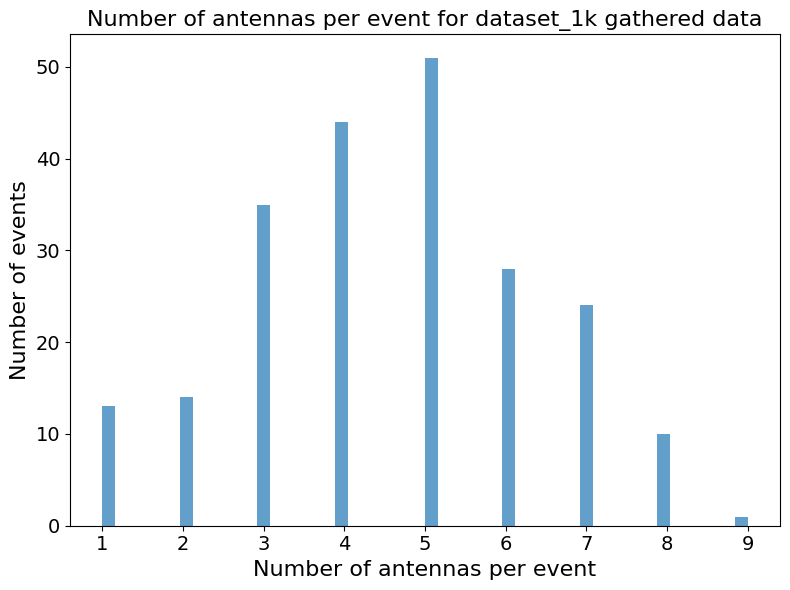

Number of traces in the dataset: 1002


In [10]:
nb_antennas_per_event = np.unique(dataset_info[:,1], return_counts=True)[1]

plt.figure(figsize=(8,6))
plt.hist(nb_antennas_per_event, 
            bins=50, 
            label='Number of antennas per event', 
            alpha=0.7)
plt.xlabel('Number of antennas per event', fontsize=16)
plt.ylabel('Number of events', fontsize=16)
plt.title(f'Number of antennas per event for {dataset_type} gathered data', fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tight_layout()
plt.savefig(f"{master_path}/plots/{dataset_type}/{name_output_dir}/nb_antennas_per_event.png")
plt.show()
plt.close()

print("Number of traces in the dataset:", dataset_info.shape[0])

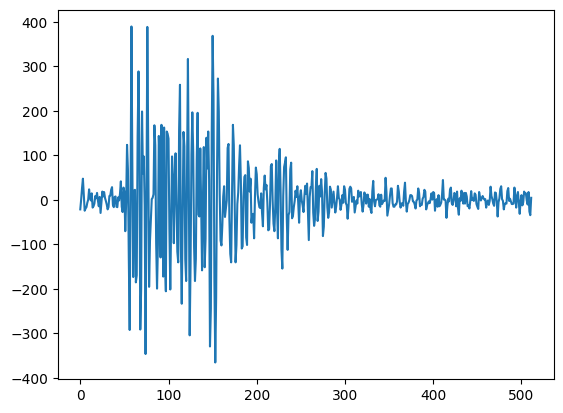

In [14]:
plt.plot(np.linspace(0, 511, 512), dataset[sigma[:,0]>70,:,0].T)
plt.show()

# Comparing datasets

In [34]:
dataset_1_traces = np.load("/sps/grand/jlavoisier/output/ML_cuts/datasets/RUNTEST_6_realCR_ANhm_noise_sigma_10_20/marion_202512_sure_567_traces.npy")
dataset_1_info = np.load("/sps/grand/jlavoisier/output/ML_cuts/datasets/RUNTEST_6_realCR_ANhm_noise_sigma_10_20/marion_202512_sure_567_info.npy")
dataset_2_traces = np.load("/sps/grand/jlavoisier/output/ML_cuts/datasets/RUNTEST_6_realCR_ANhm_noise_sigma_10_20/AN_handmade_dataset_RUNTEST_6_realCR_ANhm_noise_sigma_10_20_1525_traces.npy")
dataset_2_info = np.load("/sps/grand/jlavoisier/output/ML_cuts/datasets/RUNTEST_6_realCR_ANhm_noise_sigma_10_20/AN_handmade_dataset_RUNTEST_6_realCR_ANhm_noise_sigma_10_20_1525_info.npy")


def max_points_over_SNR_5(traces,
                          info,
                          SNR_min=5,
                          SNR_max=100) :
    """
    Entries:
    - traces: np.array of shape (nb_traces, 512, 2)
    - info: np.array of shape (nb_traces, 11)
    Ouput:
    - nb_points: int, highest number of consecutive points over SNR 5 (for traces with SNR > 5)
    """
    nb_points_dataset = np.array([])
    
    for i in range(traces.shape[0]):
        if info[i, 5] < SNR_min and info[i, 6] < SNR_min:
            continue
        nb_points = 0
        count = 0
        for j in range(512):
            if np.abs(traces[i, j, 0])/info[i,7] > SNR_min or np.abs(traces[i, j, 1])/info[i,8] > SNR_min:
                # print(np.abs(traces[i, j, 0])/info[i,7])
                count += 1
            else:
                nb_points = max(nb_points, count)
                # print(nb_points)
                count = 0
            if j == 511:
                nb_points = max(nb_points, count)
        nb_points_dataset = np.append(nb_points_dataset, nb_points)
    return nb_points_dataset

[ 2.  2.  2.  2.  2.  8.  5.  2.  3.  4.  2.  2.  2.  4. 16. 14.  9. 10.
  4.  3.  7.  9.  9. 14.  2.  7.  2.  2.  2.  2.  2.  2.  2.  2.  2.  2.
  2. 13. 10. 18. 14.  3.  6.  3.  2.  8.  4. 11.  2. 16.  8.  2.  2.  2.
 18.  3.  2. 16.  6.  6. 10.  6.  5. 14. 10. 11. 11. 16. 18.  2.  5.  2.
  2.  2.  2.  2.  2.  2.  2.  2.  2.  2.  5.  4. 22. 18. 11. 15.  8.  6.
  7.  7. 16.  2.  9.  5.  6.  2.  2.  5.  5.  7.  2.  2.  3.  2.  3.  2.
  2.  2.  6. 16. 14. 13.  5. 14.  2.  2.  6.  7.  9.  4.  9. 12.  8.  8.
  7.  4.  2.  4.  7. 10.  2. 10.  7.  7.  2.  5.  4.  2.  8.  2.  2.  4.
  3.  8.  2.  2.  4.  2.  8.  4.  2.  2.  2.  2.  2.  4.  2.  4.  7.  5.
  6.  6.  6.  2.  3.  2.  4.  7.  2.  4.  2.  2.  2.  2.  2.  2.  2.  5.
  2.  2.  2.  6.  5.  3.  2.  2.  3.  5.  7.  8.  2.  2.  5.  2.  2.  2.
 17.  9. 14.  3.  6. 16.  8.  9. 12. 16.  8.  9. 13.  7. 17.  8. 13.  6.
 17. 16.  8. 17. 16.  6.  9.  2.  2.  2.  2.  2.  4.  2.  2.  2.  2.  2.
  2.  2.  2.  2.  2.  2.  2.  2.  5.  6.  5.  2.  2

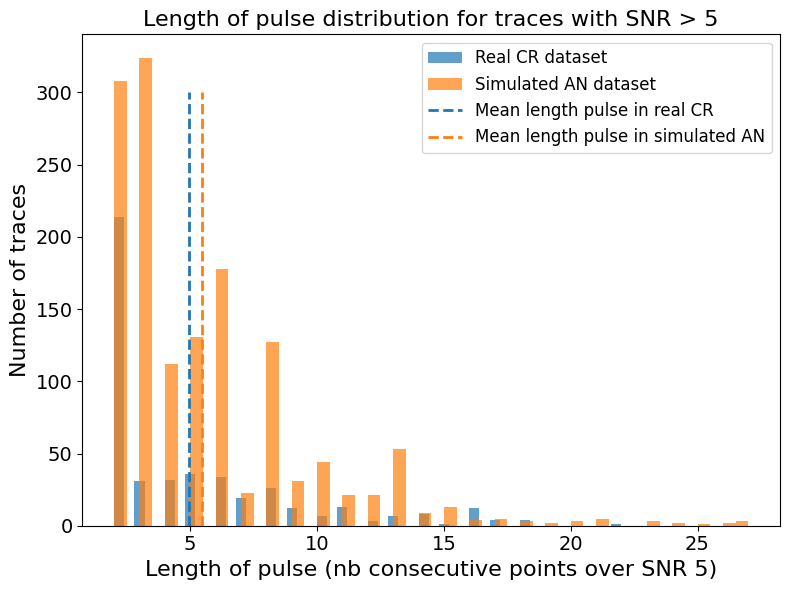

In [49]:
SNR_min=5

length_pulses_dataset_1 = max_points_over_SNR_5(dataset_1_traces,
                                                dataset_1_info,
                                                SNR_min=SNR_min)
length_pulses_dataset_2 = max_points_over_SNR_5(dataset_2_traces,
                                                dataset_2_info,
                                                SNR_min=SNR_min)

length_pulses_dataset_1 = length_pulses_dataset_1[length_pulses_dataset_1 > 1]
length_pulses_dataset_2 = length_pulses_dataset_2[length_pulses_dataset_2 > 1]

print(length_pulses_dataset_1)
print(length_pulses_dataset_2)

plt.figure(figsize=(8,6))
# plot_loghist(length_pulses_dataset_1, 
#             bins=50, 
#             label='Real CR dataset',
#             alpha=0.7)
# plot_loghist(length_pulses_dataset_2, 
#             bins=50, 
#             label='Simulated AN handmade dataset',
#             alpha=0.7)

plt.hist(length_pulses_dataset_1, 
         bins=50, 
         label='Real CR dataset',
        #  color='blue', 
         alpha=0.7
         )
plt.hist(length_pulses_dataset_2, 
         bins=50, 
         label='Simulated AN dataset',
        #  color='blue', 
         alpha=0.7
         )

plt.plot(np.zeros(10) + np.mean(length_pulses_dataset_1), 
         np.linspace(0,300, 10), 
         color='tab:blue',
         linewidth=2,
         linestyle='--',
         label='Mean length pulse in real CR'
         )

plt.plot(np.zeros(10) + np.mean(length_pulses_dataset_2), 
         np.linspace(0,300, 10), 
         color='tab:orange',
         linewidth=2,
         linestyle='--',
         label='Mean length pulse in simulated AN'
         ) # to display the means of the histograms

plt.xlabel(f'Length of pulse (nb consecutive points over SNR {SNR_min})', fontsize=16)
plt.ylabel('Number of traces', fontsize=16)
plt.title(f'Length of pulse distribution for traces with SNR > {SNR_min}', fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.legend(loc='upper right',
           fontsize=12)
plt.tight_layout()
plt.savefig(f"{master_path}/plots/RUNTEST_6_realCR_ANhm_noise_sigma_10_20/length_of_pulse_distribution_comparison.png")
plt.show()